# GPU vs CPU Benchmark — `PFNRBicop`

This notebook measures wall-clock time for **fit** and **inference** (`pdf`, `hfunc1`, `hfunc2`) on both CPU and GPU, then summarises the speedups in a table and bar chart.

## 1 · Import Required Libraries

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pyvinecopulib as pv
import torch
from dotenv import load_dotenv

load_dotenv()  # populates TABPFN_TOKEN from .env

from npcc import PFNRBicop

cuda_available = torch.cuda.is_available()
print(f"CUDA available : {cuda_available}")
if cuda_available:
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
    print(f"CUDA version   : {torch.version.cuda}")
else:
    print("No GPU found - GPU sections will be skipped.")

CUDA available : True
GPU            : NVIDIA GeForce RTX 2070 SUPER
CUDA version   : 13.0


## 2 · Simulate Training Data from Clayton Copula

In [2]:
rho = 3.0
clayton = pv.Bicop(
    family=pv.BicopFamily.clayton,
    parameters=np.asarray([[rho]], dtype=np.float64),
)
u_train = clayton.simulate(n=1000, seeds=[2, 2, 4])

# 30x30 evaluation grid used for all inference benchmarks
M = 30
u_axis = np.linspace(1 / M, 1 - 1 / M, M)
v_axis = np.linspace(1 / M, 1 - 1 / M, M)
U_mesh, V_mesh = np.meshgrid(u_axis, v_axis)
grid_uv = np.column_stack([U_mesh.flatten(), V_mesh.flatten()])

print(f"Training samples : {len(u_train)}")
print(f"Grid size        : {len(grid_uv)} points ({M}x{M})")

Training samples : 1000
Grid size        : 900 points (30x30)


## 3 · Fit and Time PFNRBicop on CPU

In [3]:
pfnr_cpu = PFNRBicop(device="cpu")

t0 = time.perf_counter()
pfnr_cpu.fit(u_train[:, 0], u_train[:, 1])
cpu_fit_time = time.perf_counter() - t0

print(f"CPU fit time : {cpu_fit_time:.2f} s")

c:\Users\flbuc\OneDrive\Documents\Research\npcc\.venv\Lib\site-packages\tabpfn\validation.py:137: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  _validate_num_samples_for_cpu(
c:\Users\flbuc\OneDrive\Documents\Research\npcc\.venv\Lib\site-packages\tabpfn\validation.py:137: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  _validate_num_samples_for_cpu(


CPU fit time : 0.99 s


## 4 · Fit and Time PFNRBicop on GPU

In [4]:
if not cuda_available:
    print("No GPU - skipping GPU fit.")
    pfnr_gpu = None
    gpu_fit_time = float("nan")
else:
    pfnr_gpu = PFNRBicop(device="cuda")

    torch.cuda.synchronize()
    t0 = time.perf_counter()
    pfnr_gpu.fit(u_train[:, 0], u_train[:, 1])
    torch.cuda.synchronize()
    gpu_fit_time = time.perf_counter() - t0

    print(f"GPU fit time : {gpu_fit_time:.2f} s")
    print(f"Speedup      : {cpu_fit_time / gpu_fit_time:.1f}x")

GPU fit time : 0.48 s
Speedup      : 2.1x


## 5 · Compare PDF Evaluation Speed

In [5]:
N_REPS = 10

# --- CPU ---
cpu_pdf_times = []
bicop_cpu = pfnr_cpu.as_bicop()
for _ in range(N_REPS):
    t0 = time.perf_counter()
    bicop_cpu.pdf(grid_uv)
    cpu_pdf_times.append(time.perf_counter() - t0)

cpu_pdf_mean = float(np.mean(cpu_pdf_times))
cpu_pdf_std = float(np.std(cpu_pdf_times))
print(f"CPU pdf  : {cpu_pdf_mean:.3f} s  +/- {cpu_pdf_std:.3f} s")

# --- GPU ---
if pfnr_gpu is not None:
    bicop_gpu = pfnr_gpu.as_bicop()
    gpu_pdf_times = []
    for _ in range(N_REPS):
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        bicop_gpu.pdf(grid_uv)
        torch.cuda.synchronize()
        gpu_pdf_times.append(time.perf_counter() - t0)

    gpu_pdf_mean = float(np.mean(gpu_pdf_times))
    gpu_pdf_std = float(np.std(gpu_pdf_times))
    print(f"GPU pdf  : {gpu_pdf_mean:.3f} s  +/- {gpu_pdf_std:.3f} s")
    print(f"Speedup  : {cpu_pdf_mean / gpu_pdf_mean:.1f}x")
else:
    gpu_pdf_mean = gpu_pdf_std = float("nan")
    print("GPU not available.")

CPU pdf  : 6.994 s  +/- 0.357 s
GPU pdf  : 0.780 s  +/- 0.094 s
Speedup  : 9.0x


## 6 · Compare h-function Evaluation Speed

In [6]:
u_flat = grid_uv[:, 0]
v_flat = grid_uv[:, 1]

def _time_fn(fn, n_reps: int, sync: bool = False) -> tuple[float, float]:
    times = []
    for _ in range(n_reps):
        if sync:
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        fn()
        if sync:
            torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)
    return float(np.mean(times)), float(np.std(times))

# CPU hfunc1
cpu_h1_mean, cpu_h1_std = _time_fn(lambda: pfnr_cpu.hfunc1(u_flat, v_flat), N_REPS)
# CPU hfunc2
cpu_h2_mean, cpu_h2_std = _time_fn(lambda: pfnr_cpu.hfunc2(u_flat, v_flat), N_REPS)

print(f"CPU hfunc1 : {cpu_h1_mean:.3f} s  +/- {cpu_h1_std:.3f} s")
print(f"CPU hfunc2 : {cpu_h2_mean:.3f} s  +/- {cpu_h2_std:.3f} s")

if pfnr_gpu is not None:
    gpu_h1_mean, gpu_h1_std = _time_fn(lambda: pfnr_gpu.hfunc1(u_flat, v_flat), N_REPS, sync=True)
    gpu_h2_mean, gpu_h2_std = _time_fn(lambda: pfnr_gpu.hfunc2(u_flat, v_flat), N_REPS, sync=True)

    print(f"GPU hfunc1 : {gpu_h1_mean:.3f} s  +/- {gpu_h1_std:.3f} s  (speedup {cpu_h1_mean/gpu_h1_mean:.1f}x)")
    print(f"GPU hfunc2 : {gpu_h2_mean:.3f} s  +/- {gpu_h2_std:.3f} s  (speedup {cpu_h2_mean/gpu_h2_mean:.1f}x)")
else:
    gpu_h1_mean = gpu_h1_std = gpu_h2_mean = gpu_h2_std = float("nan")
    print("GPU not available.")

CPU hfunc1 : 14.362 s  +/- 0.562 s
CPU hfunc2 : 14.674 s  +/- 0.285 s
GPU hfunc1 : 1.208 s  +/- 0.068 s  (speedup 11.9x)
GPU hfunc2 : 1.117 s  +/- 0.050 s  (speedup 13.1x)


## 7 · Compare tau Evaluation Speed

In [7]:
# CPU tau
cpu_tau_mean, cpu_tau_std = _time_fn(lambda: pfnr_cpu.tau(), N_REPS)
print(f"CPU tau : {cpu_tau_mean:.3f} s  +/- {cpu_tau_std:.3f} s")

if pfnr_gpu is not None:
    gpu_tau_mean, gpu_tau_std = _time_fn(lambda: pfnr_gpu.tau(), N_REPS, sync=True)
    print(f"GPU tau : {gpu_tau_mean:.3f} s  +/- {gpu_tau_std:.3f} s  (speedup {cpu_tau_mean/gpu_tau_mean:.1f}x)")
else:
    gpu_tau_mean = gpu_tau_std = float("nan")
    print("GPU not available.")

CPU tau : 7.890 s  +/- 0.264 s
GPU tau : 0.963 s  +/- 0.027 s  (speedup 8.2x)


## 8 · Benchmark Results Summary Table and Bar Chart

task         cpu_time_s   gpu_time_s    speedup
----------------------------------------------
fit               0.995        0.480        2.1x
pdf               6.994        0.780        9.0x
hfunc1           14.362        1.208       11.9x
hfunc2           14.674        1.117       13.1x
tau               7.890        0.963        8.2x


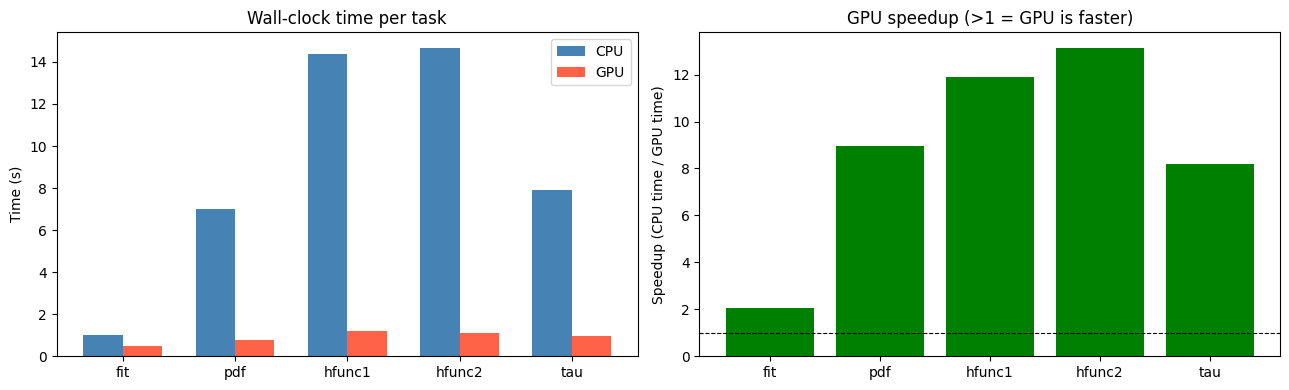

In [8]:
tasks = ["fit", "pdf", "hfunc1", "hfunc2", "tau"]
cpu_times = [cpu_fit_time, cpu_pdf_mean, cpu_h1_mean, cpu_h2_mean, cpu_tau_mean]
gpu_times = [gpu_fit_time, gpu_pdf_mean, gpu_h1_mean, gpu_h2_mean, gpu_tau_mean]
speedups = [c / g for c, g in zip(cpu_times, gpu_times)]

# --- Summary table ---
print(f"{'task':<10} {'cpu_time_s':>12} {'gpu_time_s':>12} {'speedup':>10}")
print("-" * 46)
for task, cpu, gpu, sp in zip(tasks, cpu_times, gpu_times, speedups):
    print(f"{task:<10} {cpu:>12.3f} {gpu:>12.3f} {sp:>10.1f}x")

# --- Bar chart ---
x = np.arange(len(tasks))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: absolute times
ax = axes[0]
ax.bar(x - width / 2, cpu_times, width, label="CPU", color="steelblue")
ax.bar(x + width / 2, gpu_times, width, label="GPU", color="tomato")
ax.set_xticks(x)
ax.set_xticklabels(tasks)
ax.set_ylabel("Time (s)")
ax.set_title("Wall-clock time per task")
ax.legend()

# Right: speedup
ax2 = axes[1]
colors = ["green" if s > 1 else "grey" for s in speedups]
ax2.bar(x, speedups, color=colors)
ax2.axhline(1.0, color="black", linewidth=0.8, linestyle="--")
ax2.set_xticks(x)
ax2.set_xticklabels(tasks)
ax2.set_ylabel("Speedup (CPU time / GPU time)")
ax2.set_title("GPU speedup (>1 = GPU is faster)")

plt.tight_layout()
plt.show()